<a href="https://colab.research.google.com/github/Chivirter/Chivirter/blob/main/Solar_Efficiency_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

# Set a seed so our random numbers are the same every time we run this
np.random.seed(42)
n_samples = 500

# Create the data
data = {
    'Irradiance': np.random.uniform(200, 1000, n_samples),
    'Temperature': np.random.uniform(10, 35, n_samples),
    'Humidity': np.random.uniform(30, 90, n_samples),
    'WindSpeed': np.random.uniform(0, 15, n_samples),
}

df = pd.DataFrame(data)

# Create the 'Output' (the target)
# We add a bit of 'random noise' to make it realistic (like real-world sensor error)
df['Output'] = (df['Irradiance'] * 0.6) + (df['WindSpeed'] * 0.5) - (df['Temperature'] * 0.2) + np.random.normal(0, 5, n_samples)

# Show the first 5 rows to confirm it worked
df.head()

# 1. Define Features (X) and Target (y)
X = df.drop('Output', axis=1)
y = df['Output']

# 2. Scaling the features so they are all on the same level
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data prepared and split successfully!")




All libraries imported successfully!
Data prepared and split successfully!


In [4]:
# 1. Train the Linear Regression Model (The simple baseline)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 2. Train the Random Forest Regressor (The advanced learner)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# 3. Get predictions
pred_lr = model_lr.predict(X_test)
pred_rf = model_rf.predict(X_test)

# 4. Compare Metrics
print(f"--- Linear Regression ---")
print(f"R² Score: {r2_score(y_test, pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_lr)):.2f}")

print(f"\n--- Random Forest ---")
print(f"R² Score: {r2_score(y_test, pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.2f}")

--- Linear Regression ---
R² Score: 0.9985
RMSE: 5.43

--- Random Forest ---
R² Score: 0.9981
RMSE: 6.13


/tmp/ipykernel_3942/1560042535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.sort_values(by='Importance', ascending=False), palette='viridis')


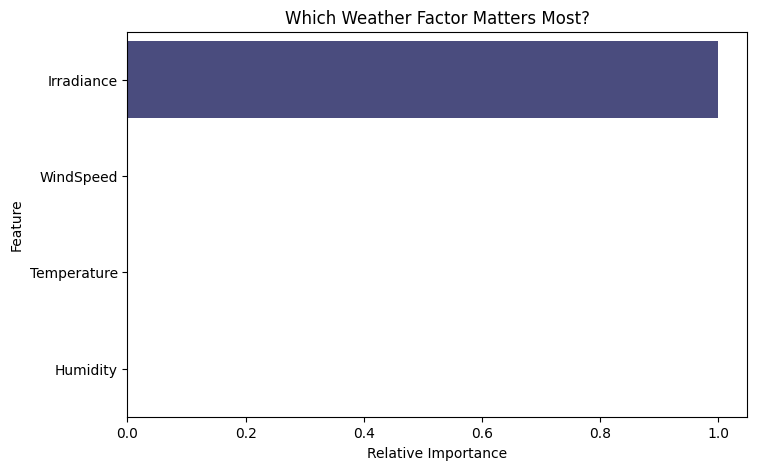

In [5]:
# Extract feature importances from the Random Forest model
importances = model_rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df.sort_values(by='Importance', ascending=False), palette='viridis')
plt.title('Which Weather Factor Matters Most?')
plt.xlabel('Relative Importance')
plt.show()

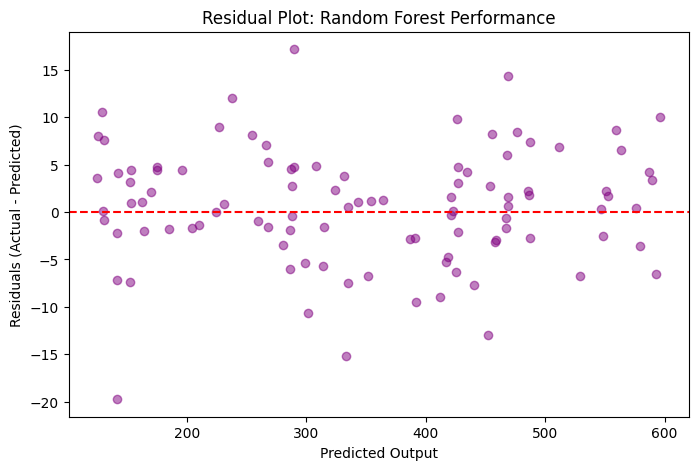

In [6]:
# Create a Residual Plot for the Random Forest model
residuals = y_test - pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(pred_rf, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Random Forest Performance')
plt.xlabel('Predicted Output')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()